# 4. Universal Kriging 



**Dataset:** Jura geochemical survey (`data/jura_data.csv`, `data/jura_grid.csv`)  

**Target:** Cadmium (Cd, mg/kg)

**Library:** `pygstat` v0.1.0  

***



## Table of Contents

1. [Overview](#1-overview)
2. [What is Universal Kriging?](#2-what-is-universal-kriging)
3. [How Universal Kriging Works](#3-how-universal-kriging-works)
4. [Python Setup](#4-python-setup)
   - 4.1 [CPU and GPU](#41-cpu-and-gpu)
5. [Load and Explore the Jura Data](#5-load-and-explore-the-jura-data)
6. [Stratified Train / Test Split](#6-stratified-train--test-split)
7. [Trend Analysis by Polynomial Degree](#7-trend-analysis-by-polynomial-degree)
8. [Residual Variogram on the Best Trend](#8-residual-variogram-on-the-best-trend)
9. [Fit Universal Kriging](#9-fit-universal-kriging)
10. [Validate UK on the Test Set](#10-validate-uk-on-the-test-set)
11. [Predict Cd on the Jura Grid](#11-predict-cd-on-the-jura-grid)
12. [Map Predicted Concentration and Error](#12-map-predicted-concentration-and-error)
13. [Probability Maps of Exceedance](#13-probability-maps-of-exceedance)
14. [CPU vs GPU UK Timing](#14-cpu-vs-gpu-uk-timing)
15. [Summary and Conclusions](#15-summary-and-conclusions)
16. [Resources](#16-resources)


***
## 1. Overview

**Universal Kriging (UK)** interpolates a random field whose **mean is a function of location** — a polynomial drift — rather than a known constant (simple kriging) or an unknown constant (ordinary kriging). The residual after removing that drift is treated as a zero-mean stationary process whose spatial structure is described by a variogram.

This tutorial applies UK to **cadmium (Cd)** in the Swiss Jura using PyGStat, with the same Landuse-stratified split as Tutorials 03 and 04:

| Step | What we do |
|------|------------|
| Data | Load `jura_data.csv` (359 samples) and `jura_grid.csv` (prediction nodes) |
| Split | Stratified 70% / 30% train–test split by **Landuse** |
| Trend analysis | Fit coordinate polynomials of degree 0, 1, 2 (and 3) on the **training** set; pick the best drift by AIC |
| Residual variogram | Fit spherical, exponential, gaussian, Matérn, stable, and cubic models to **trend residuals**; pick the best by AIC |
| Universal Kriging | Fit `UniversalKriging` with the chosen degree and residual variogram |
| Validation | Predict held-out test locations; report RMSE, MAE, $R^2$, and mean error |
| Mapping | Predict Cd and kriging standard error on the Jura grid |
| Probability | Map $P(\text{Cd} > z_c)$ for $z_c \in \{0.10, 0.25, 0.50, 0.75, 1.00\}$ mg/kg |
| CPU / GPU | Time `UniversalKriging.predict` on CPU vs GPU for Jura Cd and Great Plains SOC (`gp_data_5000.csv`) |

By the end you will have chosen a spatial trend, fitted a residual variogram, validated UK, mapped Cd, its error, and Gaussian exceedance probabilities, and seen when a GPU pays off for UK.

***
## 2. What is Universal Kriging?

Write the random field as a **deterministic drift** plus a **zero-mean residual**:

$$
Z(\mathbf{x}) = m(\mathbf{x}) + R(\mathbf{x}), \qquad \mathbb{E}[R(\mathbf{x})] = 0.
$$

Universal kriging takes $m(\mathbf{x})$ to be a polynomial in the coordinates. In two dimensions:

| Degree | Drift $m(x,y)$ | # of trend coefficients |
|--------|----------------|-------------------------|
| 0 | $\beta_0$ (constant) | 1 — same as ordinary kriging |
| 1 | $\beta_0 + \beta_1 x + \beta_2 y$ | 3 — linear (planar) trend |
| 2 | $\beta_0 + \beta_1 x + \beta_2 y + \beta_3 x^2 + \beta_4 xy + \beta_5 y^2$ | 6 — quadratic |
| 3 | cubic terms added | 10 |

The UK predictor is still a linear combination of the data,

$$
\hat{Z}_{\text{UK}}(\mathbf{x}_0) = \sum_{i=1}^{n} \lambda_i\, Z(\mathbf{x}_i),
$$

but the weights are constrained so that the predictor is **unbiased for every coefficient of the drift**. For a linear trend that means

$$
\sum_i \lambda_i = 1, \quad \sum_i \lambda_i x_i = x_0, \quad \sum_i \lambda_i y_i = y_0.
$$

### Assumptions

| Assumption | Meaning |
|------------|---------|
| Known form of the drift | Polynomial degree is chosen; coefficients are unknown |
| Stationary residuals | $R(\mathbf{x})$ has a well-defined variogram $\gamma_R(h)$ |
| Variogram of residuals known | $\gamma_R$ is fitted from training residuals after a first-pass trend |

### UK vs SK vs OK

| | Simple Kriging | Ordinary Kriging | Universal Kriging |
|---|---|---|---|
| Mean | Known constant $m$ | Unknown constant | Unknown polynomial $m(\mathbf{x})$ |
| Constraints | none on $\sum\lambda_i$ | $\sum\lambda_i=1$ | $\mathbf{F}^\top\boldsymbol{\lambda} = \mathbf{f}(\mathbf{x}_0)$ |
| Variogram | of $Z$ | of $Z$ (increments) | of **residuals** $R$ |
| When to use | Stationary field, trusted mean | Mild unknown mean | Clear spatial trend (slope, bowl, …) |

***
## 3. How Universal Kriging Works

### 3.1 Two-step residual approach (used here)

A rigorous UK fit is circular: the residual variogram needs the trend, and the trend is estimated jointly with the kriging weights. The standard practical solution is:

1. Fit an ordinary-least-squares (OLS) polynomial of degree $d$ to the **training** coordinates.
2. Compare degrees with AIC / adjusted $R^2$ and residual maps; choose $d^\star$.
3. Compute residuals $r_i = z_i - \hat{m}_{d^\star}(\mathbf{x}_i)$.
4. Fit a theoretical variogram to $\{r_i\}$.
5. Solve the UK system with that residual covariance and the same polynomial basis.

`pygstat.UniversalKriging` implements step 5: it builds the polynomial design matrix with `sklearn.PolynomialFeatures(degree, include_bias=True)` and solves the augmented kriging system. **You must pass a variogram of residuals**, not of raw Cd.

### 3.2 The UK linear system

Let $\mathbf{F}$ be the $n \times p$ trend matrix (rows are $1, x, y, \ldots$ at training points) and $\mathbf{f}_0$ the same basis at $\mathbf{x}_0$. With residual covariance $\mathbf{C}$,

$$
\begin{bmatrix} \mathbf{C} & \mathbf{F} \\ \mathbf{F}^\top & \mathbf{0} \end{bmatrix}
\begin{bmatrix} \boldsymbol{\lambda} \\ \boldsymbol{\mu} \end{bmatrix}
=
\begin{bmatrix} \mathbf{c}_0 \\ \mathbf{f}_0 \end{bmatrix}.
$$

Then $\hat{Z}_{\text{UK}}(\mathbf{x}_0) = \boldsymbol{\lambda}^\top \mathbf{z}$. The Lagrange vector $\boldsymbol{\mu}$ enforces unbiasedness for each trend coefficient.

### 3.3 Kriging variance

$$
\sigma^2_{\text{UK}}(\mathbf{x}_0) = C(0) - \boldsymbol{\lambda}^\top \mathbf{c}_0 - \boldsymbol{\mu}^\top \mathbf{f}_0.
$$

UK variance is larger than OK/SK variance because more mean parameters are estimated. `predict(..., return_variance=True)` returns $\sigma_{\text{UK}} = \sqrt{\sigma^2_{\text{UK}}}$.

### 3.4 Gaussian exceedance probability

$$
P\bigl(Z(\mathbf{x}_0) > z_c\bigr) = 1 - \Phi\!\left(\frac{z_c - \hat{Z}_{\text{UK}}(\mathbf{x}_0)}{\sigma_{\text{UK}}(\mathbf{x}_0)}\right).
$$

This inherits the Gaussian residual assumption. Indicator kriging is the distribution-free alternative.

### 3.5 Workflow in this notebook

1. Split samples **by Landuse**.
2. Compare polynomial drifts of degree 0–3 on training Cd; choose $d^\star$ by AIC.
3. Fit residual variogram models; choose the best by AIC.
4. Fit `UniversalKriging(variogram, degree=d★)` on the training coordinates and Cd.
5. Validate on the test set; map the grid; compute $P(\text{Cd} > z_c)$.

***
## 4. Python Setup

### 4.1 CPU and GPU

PyGStat's `UniversalKriging` builds the covariance matrix and solves the augmented kriging system on **CPU** (NumPy/SciPy) or **GPU** (CuPy). Pass `use_gpu` as:

| Value | Behaviour |
|-------|-----------|
| `'auto'` (default) | GPU when CuPy can run a kernel on this card. Falls back to CPU otherwise. |
| `True` | Force GPU. Warns and falls back to CPU if CuPy is missing or cannot run a kernel. |
| `False` | Always CPU (NumPy/SciPy). |

This notebook probes the GPU once with `cupy_gpu_usable()` (a real op, not just `import cupy`) and stores the result in `USE_GPU`. The UK fit below passes `use_gpu=USE_GPU`, so the same cells run on a laptop CPU or a CUDA workstation without edits.

Three caveats:

- The **polynomial drift matrix** (`sklearn.PolynomialFeatures`) is always built on CPU. That step is cheap next to the $O(n^3)$ solve, which is where the GPU matters.
- The **Matérn** model always *evaluates* on CPU (SciPy Bessel functions have no CuPy equivalent). The UK linear algebra is still GPU-accelerated when `USE_GPU` is true.
- **Small $n$** (a few hundred training points, like Jura) often shows little GPU gain *unless* you predict a large grid: host→device copies and kernel-launch overhead can dominate a small $n \times n$ system.

Install CuPy with `pip install pygstat[gpu]` (CUDA 11) or `pip install cupy-cuda12x` for CUDA 12.

Section 14 times `UniversalKriging.predict` on both backends using Jura Cd and prefixes of `data/gp_data_5000.csv`.


In [1]:
%matplotlib inline
import sys, os, warnings
warnings.filterwarnings("ignore")
sys.path.insert(0, os.path.abspath("../src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm, skew
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

import pygstat
from pygstat import Variogram, UniversalKriging
from pygstat.utils.backend import CUPY_AVAILABLE, cupy_gpu_usable

print(f"pygstat version : {pygstat.__version__}")
print(f"NumPy           : {np.__version__}")
print(f"pandas          : {pd.__version__}")

# ── CPU / GPU dispatch ────────────────────────────────────────────────────────
# cupy_gpu_usable() runs a real kernel (not just `import cupy`). Older cards can
# import CuPy and still fail at compile time; those stay on CPU.
USE_GPU = cupy_gpu_usable()
if USE_GPU:
    import cupy as cp
    print(f"CuPy            : {cp.__version__}")
    try:
        name = cp.cuda.runtime.getDeviceProperties(0)["name"]
        if isinstance(name, bytes):
            name = name.decode()
        print(f"GPU             : {name}")
    except Exception:
        print("GPU             : available")
    print("Backend         : GPU (CuPy) — UK covariance + solve on GPU")
else:
    if CUPY_AVAILABLE:
        import cupy as cp
        print(f"CuPy            : {cp.__version__} (installed, but cannot run a kernel on this GPU/CUDA setup)")
    else:
        print("CuPy            : not installed  (pip install pygstat[gpu]  or  cupy-cuda12x)")
    print("Backend         : CPU (NumPy)")
print(f"use_gpu         : {USE_GPU}")


I0000 00:00:1788925369.365887  551375 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


pygstat version : 0.1.0
NumPy           : 2.4.6
pandas          : 3.0.3
CuPy            : 14.2.0
GPU             : NVIDIA GeForce RTX 2080 Ti
Backend         : GPU (CuPy) — UK covariance + solve on GPU
use_gpu         : True


***
## 5. Load and Explore the Jura Data

The **Jura dataset** (Goovaerts, 1997) contains 359 soil samples of heavy metals in the Swiss Jura. We model **Cd** at sample locations and predict it on `jura_grid.csv`.

Land-use codes in the sample file are integers (`1`–`4`). The stratified split uses that integer column.

In [2]:
df = pd.read_csv("../data/jura_data.csv")
grid = pd.read_csv("../data/jura_grid.csv")

print("Samples:", df.shape, "  Grid:", grid.shape)
print("Sample columns:", list(df.columns))
print("Grid columns:  ", list(grid.columns))
df.head()

Samples: (359, 12)   Grid: (5957, 5)
Sample columns: ['Unnamed: 0', 'Xloc', 'Yloc', 'Landuse', 'Rock', 'Cd', 'Co', 'Cr', 'Cu', 'Ni', 'Pb', 'Zn']
Grid columns:   ['Unnamed: 0', 'Xloc', 'Yloc', 'Landuse', 'Rock']


,Unnamed: 0,Xloc,Yloc,Landuse,Rock,Cd,Co,Cr,Cu,Ni,Pb,Zn
0,1,2.386,3.077,3,3,1.740,9.32,38.32,25.72,21.32,77.36,92.56
1,2,2.544,1.972,2,2,1.335,10.00,40.20,24.76,29.72,77.88,73.56
2,3,2.807,3.347,2,3,1.610,10.60,47.00,8.88,21.40,30.80,64.80
3,4,4.308,1.933,3,2,2.150,11.92,43.52,22.70,29.72,56.40,90.00
4,5,4.383,1.081,3,5,1.565,16.32,38.52,34.32,26.20,66.40,88.40


In [3]:
target = "Cd"
x_col, y_col = "Xloc", "Yloc"
strata_col = "Landuse"

coords = df[[x_col, y_col]].values
z = df[target].values.astype(float)
grid_coords = grid[[x_col, y_col]].values

print(f"\n{target} (mg/kg) summary:")
print(df[target].describe().round(3))
print(f"Skewness: {skew(z):.3f}")
print(f"\nLanduse counts:\n{df[strata_col].value_counts().sort_index().to_string()}")


Cd (mg/kg) summary:
count    359.000
mean       1.288
std        0.859
min        0.135
25%        0.653
50%        1.100
75%        1.680
max        5.129
Name: Cd, dtype: float64
Skewness: 1.472

Landuse counts:
Landuse
1     51
2     82
3    218
4      8


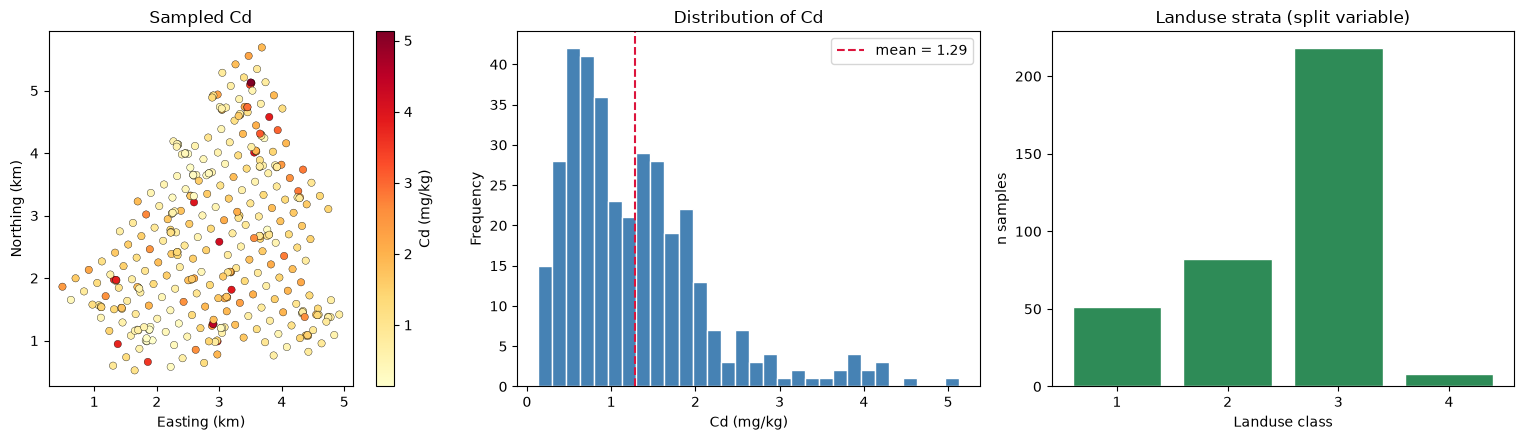

Grid extent: X [0.30, 5.10], Y [0.10, 5.90] km  (5957 nodes)


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

sc = axes[0].scatter(df[x_col], df[y_col], c=z, cmap="YlOrRd", s=28,
                     edgecolors="k", linewidths=0.25)
plt.colorbar(sc, ax=axes[0], label=f"{target} (mg/kg)")
axes[0].set_title(f"Sampled {target}")
axes[0].set_xlabel("Easting (km)"); axes[0].set_ylabel("Northing (km)")
axes[0].set_aspect("equal")

axes[1].hist(z, bins=30, color="steelblue", edgecolor="white")
axes[1].axvline(z.mean(), color="crimson", ls="--", label=f"mean = {z.mean():.2f}")
axes[1].set_title(f"Distribution of {target}")
axes[1].set_xlabel(f"{target} (mg/kg)"); axes[1].set_ylabel("Frequency")
axes[1].legend()

land_counts = df[strata_col].value_counts().sort_index()
axes[2].bar(land_counts.index.astype(str), land_counts.values, color="seagreen", edgecolor="white")
axes[2].set_title("Landuse strata (split variable)")
axes[2].set_xlabel("Landuse class"); axes[2].set_ylabel("n samples")

plt.tight_layout(); plt.show()

print(f"Grid extent: X [{grid[x_col].min():.2f}, {grid[x_col].max():.2f}], "
      f"Y [{grid[y_col].min():.2f}, {grid[y_col].max():.2f}] km  ({len(grid)} nodes)")

***
## 6. Stratified Train / Test Split

**Stratified random sampling** draws the 70% / 30% split inside each Landuse class. Trend, residual variogram, and UK are all fitted on the **training** set only. The split seed matches Tutorials 03–04 (`random_state=42`).

In [5]:
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.30, random_state=42)
train_idx, test_idx = next(sss.split(df, df[strata_col]))

df_train = df.iloc[train_idx].reset_index(drop=True)
df_test  = df.iloc[test_idx].reset_index(drop=True)

coords_train = df_train[[x_col, y_col]].values
coords_test  = df_test[[x_col, y_col]].values
z_train = df_train[target].values.astype(float)
z_test  = df_test[target].values.astype(float)

print(f"Train: {len(df_train)} ({100*len(df_train)/len(df):.1f}%)")
print(f"Test:  {len(df_test)} ({100*len(df_test)/len(df):.1f}%)")

prop = pd.DataFrame({
    "all":    df[strata_col].value_counts(normalize=True).sort_index(),
    "train":  df_train[strata_col].value_counts(normalize=True).sort_index(),
    "test":   df_test[strata_col].value_counts(normalize=True).sort_index(),
})
prop.index.name = "Landuse"
(prop * 100).round(1)

Train: 251 (69.9%)
Test:  108 (30.1%)


,all,train,test
Landuse,,,
1,14.2,14.3,13.9
2,22.8,22.7,23.1
3,60.7,60.6,61.1
4,2.2,2.4,1.9


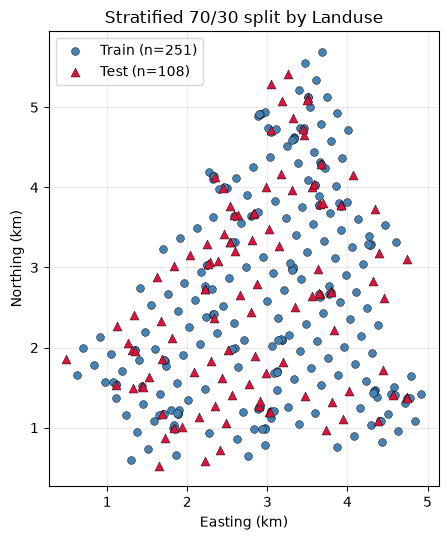

In [6]:
fig, ax = plt.subplots(figsize=(6.5, 5.5))
ax.scatter(df_train[x_col], df_train[y_col], c="steelblue", s=32,
           edgecolors="k", linewidths=0.3, label=f"Train (n={len(df_train)})", zorder=3)
ax.scatter(df_test[x_col], df_test[y_col], c="crimson", s=42, marker="^",
           edgecolors="k", linewidths=0.3, label=f"Test (n={len(df_test)})", zorder=4)
ax.set_aspect("equal")
ax.set_xlabel("Easting (km)"); ax.set_ylabel("Northing (km)")
ax.set_title("Stratified 70/30 split by Landuse")
ax.legend(frameon=True); ax.grid(alpha=0.25)
plt.tight_layout(); plt.show()

***
## 7. Trend Analysis by Polynomial Degree

Before kriging we ask whether Cd has a **spatial drift**. Degree 0 is a constant mean (ordinary kriging). Degrees 1–3 add linear, quadratic, and cubic terms in $(x,y)$.

We fit each polynomial by OLS on the **training** set and compare:

| Metric | Role |
|--------|------|
| $R^2$ / adj. $R^2$ | How much of Cd the coordinates explain |
| AIC / BIC | Penalise extra coefficients (prefer parsimony) |
| Residual RMSE | Scatter left for the variogram |
| Residual maps | A good drift should remove broad spatial gradients |

The degree with the **lowest AIC** is used for UK. Higher degrees can overfit; a cubic surface with 10 coefficients on 251 points is often too flexible.

In [7]:
def fit_trend(coords, values, degree):
    """OLS polynomial drift. degree=0 is a constant mean."""
    n = len(values)
    if degree == 0:
        F = np.ones((n, 1))
        beta = np.array([float(np.mean(values))])
        fitted = np.full(n, beta[0])
        names = ["1"]
    else:
        poly = PolynomialFeatures(degree=degree, include_bias=True)
        F = poly.fit_transform(coords)
        names = list(poly.get_feature_names_out(["x", "y"]))
        lm = LinearRegression(fit_intercept=False)
        lm.fit(F, values)
        beta = lm.coef_.astype(float)
        fitted = lm.predict(F)
    resid = values - fitted
    p = F.shape[1]
    rss = float(np.sum(resid ** 2))
    tss = float(np.sum((values - values.mean()) ** 2))
    r2 = 1.0 - rss / tss if tss > 0 else np.nan
    adj_r2 = 1.0 - (1.0 - r2) * (n - 1) / (n - p) if n > p else np.nan
    aic = n * np.log(rss / n) + 2 * p
    bic = n * np.log(rss / n) + p * np.log(n)
    rmse = float(np.sqrt(rss / n))
    return {
        "degree": degree, "p": p, "names": names, "beta": beta,
        "fitted": fitted, "resid": resid, "F": F,
        "R2": r2, "adj_R2": adj_r2, "AIC": aic, "BIC": bic, "RMSE": rmse,
    }


degrees = [0, 1, 2, 3]
trends = {d: fit_trend(coords_train, z_train, d) for d in degrees}

trend_table = pd.DataFrame([
    {"degree": t["degree"], "n_coef": t["p"],
     "R2": round(t["R2"], 4), "adj_R2": round(t["adj_R2"], 4),
     "RMSE": round(t["RMSE"], 4), "AIC": round(t["AIC"], 3), "BIC": round(t["BIC"], 3)}
    for t in trends.values()
]).set_index("degree")

best_degree = int(trend_table["AIC"].idxmin())
print("Trend comparison on training Cd")
print(trend_table.to_string())
print(f"\n>>> BEST TREND DEGREE: {best_degree} (lowest AIC) <<<")
print("Basis:", trends[best_degree]["names"])
print("Coefficients:", np.round(trends[best_degree]["beta"], 4))
trend_table.style.background_gradient(subset=["AIC"], cmap="RdYlGn_r")

Trend comparison on training Cd
        n_coef      R2  adj_R2    RMSE      AIC     BIC
degree                                                 
0            1  0.0000  0.0000  0.8442  -83.003 -79.477
1            3  0.0112  0.0032  0.8395  -81.830 -71.253
2            6  0.0659  0.0468  0.8159  -90.114 -68.962
3           10  0.1318  0.0993  0.7867 -100.466 -65.211

>>> BEST TREND DEGREE: 3 (lowest AIC) <<<
Basis: ['1', 'x', 'y', 'x^2', 'x y', 'y^2', 'x^3', 'x^2 y', 'x y^2', 'y^3']
Coefficients: [-0.4969 -0.1247  2.505   0.545  -1.0237 -0.5758 -0.1007  0.1265  0.0786
  0.0441]


,n_coef,R2,adj_R2,RMSE,AIC,BIC
degree,,,,,,
0,1,0.000000,0.000000,0.844200,-83.003000,-79.477000
1,3,0.011200,0.003200,0.839500,-81.830000,-71.253000
2,6,0.065900,0.046800,0.815900,-90.114000,-68.962000
3,10,0.131800,0.099300,0.786700,-100.466000,-65.211000


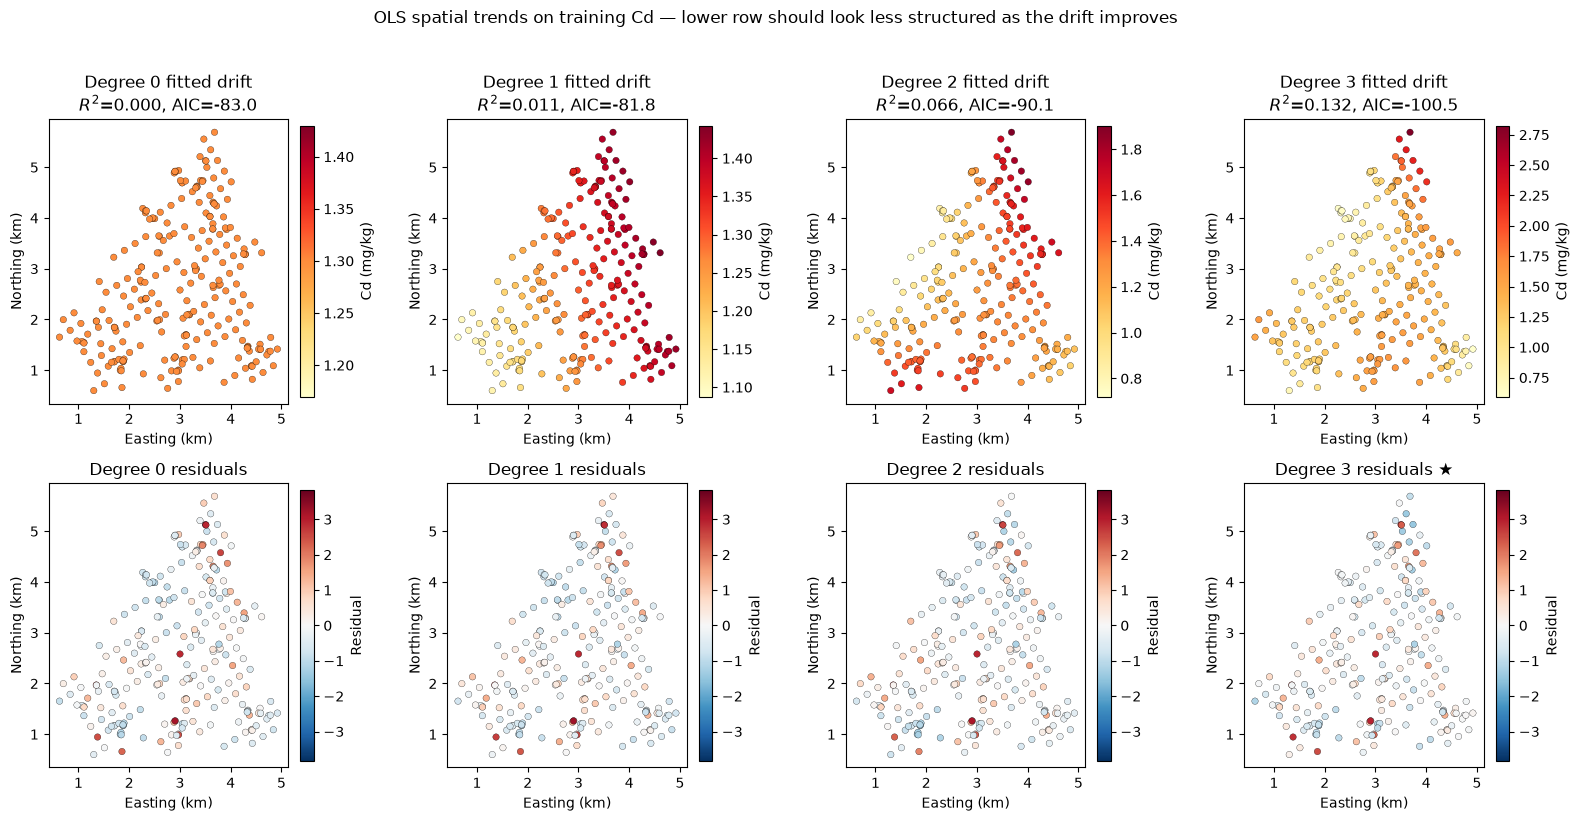

In [8]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
vmax_r = max(np.max(np.abs(trends[d]["resid"])) for d in degrees)

for j, d in enumerate(degrees):
    t = trends[d]
    sc0 = axes[0, j].scatter(df_train[x_col], df_train[y_col], c=t["fitted"],
                             cmap="YlOrRd", s=22, edgecolors="k", linewidths=0.2)
    axes[0, j].set_aspect("equal")
    axes[0, j].set_title(f"Degree {d} fitted drift\n$R^2$={t['R2']:.3f}, AIC={t['AIC']:.1f}")
    axes[0, j].set_xlabel("Easting (km)"); axes[0, j].set_ylabel("Northing (km)")
    plt.colorbar(sc0, ax=axes[0, j], fraction=0.046, pad=0.04, label="Cd (mg/kg)")

    sc1 = axes[1, j].scatter(df_train[x_col], df_train[y_col], c=t["resid"],
                             cmap="RdBu_r", s=22, edgecolors="k", linewidths=0.2,
                             vmin=-vmax_r, vmax=vmax_r)
    axes[1, j].set_aspect("equal")
    star = " ★" if d == best_degree else ""
    axes[1, j].set_title(f"Degree {d} residuals{star}")
    axes[1, j].set_xlabel("Easting (km)"); axes[1, j].set_ylabel("Northing (km)")
    plt.colorbar(sc1, ax=axes[1, j], fraction=0.046, pad=0.04, label="Residual")

plt.suptitle("OLS spatial trends on training Cd — lower row should look less structured as the drift improves",
             fontsize=12, y=1.02)
plt.tight_layout(); plt.show()

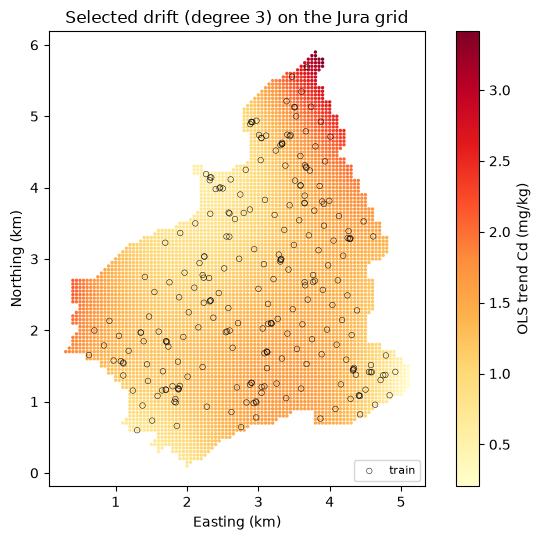

Residual mean (should be ~0): +0.0000
Residual std:                 0.7867 mg/kg


In [9]:
# Smooth trend surface of the winning degree, evaluated on the prediction grid
t_best = trends[best_degree]
if best_degree == 0:
    trend_grid = np.full(len(grid_coords), t_best["beta"][0])
else:
    poly_best = PolynomialFeatures(degree=best_degree, include_bias=True)
    poly_best.fit(coords_train)
    trend_grid = poly_best.transform(grid_coords) @ t_best["beta"]

fig, ax = plt.subplots(figsize=(6.5, 5.5))
sc = ax.scatter(grid[x_col], grid[y_col], c=trend_grid, cmap="YlOrRd", s=8, marker=".")
ax.scatter(df_train[x_col], df_train[y_col], facecolors="none", edgecolors="k",
           s=16, linewidths=0.35, label="train")
plt.colorbar(sc, ax=ax, label="OLS trend Cd (mg/kg)")
ax.set_aspect("equal")
ax.set_title(f"Selected drift (degree {best_degree}) on the Jura grid")
ax.set_xlabel("Easting (km)"); ax.set_ylabel("Northing (km)")
ax.legend(loc="lower right", fontsize=8)
plt.tight_layout(); plt.show()

resid_train = t_best["resid"]
print(f"Residual mean (should be ~0): {resid_train.mean():+.4f}")
print(f"Residual std:                 {resid_train.std():.4f} mg/kg")

***
## 8. Residual Variogram on the Best Trend

UK models spatial correlation of the **residuals**, not of raw Cd. We fit all six theoretical models to the training residuals of the selected drift and rank them by AIC.

In [10]:
def find_best_variogram(coords, values, estimator="matheron", n_lags=15,
                        criterion="AIC", verbose=True):
    """Fit all standard models; return the best Variogram by ``criterion``."""
    models = ["spherical", "exponential", "gaussian", "matern", "stable", "cubic"]
    n_params = {"spherical": 3, "exponential": 3, "gaussian": 3,
                "matern": 4, "stable": 4, "cubic": 3}
    fitted, records = {}, []

    for model_name in models:
        v = Variogram(coords=np.asarray(coords, dtype=float),
                      values=np.asarray(values, dtype=float),
                      model=model_name, estimator=estimator, n_lags=n_lags)
        v.fit()
        obs = v.experimental
        mask = ~np.isnan(obs)
        obs_v, pred = obs[mask], v(v.lags)[mask]
        K, p = mask.sum(), n_params[model_name]
        rss = float(np.sum((pred - obs_v) ** 2))
        tss = float(np.sum((obs_v - obs_v.mean()) ** 2))
        r2 = 1.0 - rss / tss if tss > 0 else np.nan
        aic = K * np.log(rss / K) + 2 * p if rss > 0 else -np.inf
        bic = K * np.log(rss / K) + p * np.log(K) if rss > 0 else -np.inf
        fitted[model_name] = v
        extra = round(float(v.fitted_params[3]), 4) if len(v.fitted_params) > 3 else "—"
        records.append({
            "Model": model_name.capitalize(),
            "Nugget": round(float(v.fitted_params[0]), 5),
            "Sill":   round(float(v.fitted_params[1]), 5),
            "Range":  round(float(v.fitted_params[2]), 5),
            "Extra":  extra,
            "RSS":    round(rss, 6),
            "R²":     round(r2, 4),
            "AIC":    round(aic, 4),
            "BIC":    round(bic, 4),
        })

    df_results = pd.DataFrame(records).set_index("Model")
    df_results = df_results.sort_values(criterion, ascending=(criterion != "R²"))
    best_cap = df_results.index[0]
    if verbose:
        print(df_results.to_string())
        print(f"\n>>> BEST RESIDUAL MODEL: {best_cap} (by {criterion}) <<<")
    return best_cap, fitted[best_cap.lower()], df_results, fitted


print(f"Fitting residual variograms (trend degree = {best_degree})\n")
best_name, vg_best, df_rank, fitted_models = find_best_variogram(
    coords_train, resid_train, estimator="matheron", n_lags=12, criterion="AIC"
)

Fitting residual variograms (trend degree = 3)

              Nugget     Sill    Range   Extra       RSS      R²      AIC      BIC
Model                                                                             
Cubic        0.55813  0.03464  0.71914       —  0.024746  0.0428 -68.2080 -66.7533
Spherical    0.55249  0.04018  0.59798       —  0.024770  0.0418 -68.1965 -66.7418
Gaussian     0.58818  0.00000  0.92307       —  0.025851 -0.0000 -67.6836 -66.2289
Exponential  0.58818  0.00000  0.95109       —  0.025851 -0.0000 -67.6836 -66.2289
Matern       0.58818  0.00000  1.20519  1.5773  0.025851 -0.0000 -65.6836 -63.7440
Stable       0.58805  0.00022  0.96200  0.6671  0.025851  0.0000 -65.6836 -63.7440

>>> BEST RESIDUAL MODEL: Cubic (by AIC) <<<


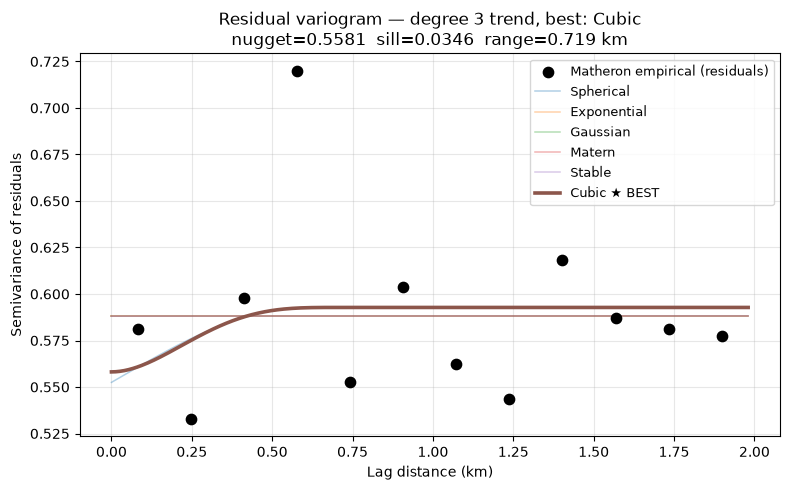

,Nugget,Sill,Range,Extra,RSS,R²,AIC,BIC
Model,,,,,,,,
Cubic,0.558130,0.034640,0.719140,—,0.024746,0.042800,-68.208000,-66.753300
Spherical,0.552490,0.040180,0.597980,—,0.024770,0.041800,-68.196500,-66.741800
Gaussian,0.588180,0.000000,0.923070,—,0.025851,-0.000000,-67.683600,-66.228900
Exponential,0.588180,0.000000,0.951090,—,0.025851,-0.000000,-67.683600,-66.228900
Matern,0.588180,0.000000,1.205190,1.577300,0.025851,-0.000000,-65.683600,-63.744000
Stable,0.588050,0.000220,0.962000,0.667100,0.025851,0.000000,-65.683600,-63.744000


In [11]:
h_fine = np.linspace(0, vg_best.maxlag, 300)
palette = {"Spherical": "#1f77b4", "Exponential": "#ff7f0e", "Gaussian": "#2ca02c",
           "Matern": "#d62728", "Stable": "#9467bd", "Cubic": "#8c564b"}

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(vg_best.lags, vg_best.experimental, color="black", s=55, zorder=6,
           label="Matheron empirical (residuals)")
for name, v in fitted_models.items():
    cap = name.capitalize()
    is_best = cap == best_name
    ax.plot(h_fine, v(h_fine), color=palette.get(cap, "gray"),
            lw=2.6 if is_best else 1.1,
            alpha=1.0 if is_best else 0.35,
            label=cap + (" ★ BEST" if is_best else ""))
p = vg_best.fitted_params
ax.set_title(f"Residual variogram — degree {best_degree} trend, best: {best_name}\n"
             f"nugget={p[0]:.4f}  sill={p[1]:.4f}  range={p[2]:.3f} km")
ax.set_xlabel("Lag distance (km)"); ax.set_ylabel("Semivariance of residuals")
ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

df_rank.style.background_gradient(subset=["AIC", "RSS"], cmap="RdYlGn_r")

***
## 9. Fit Universal Kriging

`UniversalKriging` takes the **residual** variogram and the chosen polynomial `degree`. The response passed to `fit` is still raw Cd: UK estimates the drift and the residual field jointly through the augmented system. `use_gpu=USE_GPU` builds the covariance matrix and solves the UK system on CuPy when a usable GPU is present.


In [12]:
uk = UniversalKriging(vg_best, degree=best_degree, use_gpu=USE_GPU).fit(coords_train, z_train)

print(f"Estimator               : Universal Kriging")
print(f"Trend degree            : {uk.degree}")
print(f"Trend basis columns     : {uk.F.shape[1]}  {list(uk._poly.get_feature_names_out(['x','y'])) if best_degree > 0 else ['1']}")
print(f"Residual variogram      : {vg_best.model}")
print(f"Fitted params [C0, C, a]: {np.round(vg_best.fitted_params[:3], 5)}")
print(f"Training n              : {len(z_train)}")
print(f"use_gpu                : {uk.use_gpu}")


Estimator               : Universal Kriging
Trend degree            : 3
Trend basis columns     : 10  ['1', 'x', 'y', 'x^2', 'x y', 'y^2', 'x^3', 'x^2 y', 'x y^2', 'y^3']
Residual variogram      : cubic
Fitted params [C0, C, a]: [0.55813 0.03464 0.71914]
Training n              : 251
use_gpu                : True


***
## 10. Validate UK on the Test Set

Predict Cd at the **held-out** 30% of samples. Trend degree and residual variogram were estimated from training data only.

In [13]:
z_hat, se_test = uk.predict(coords_test, return_variance=True)

rmse = float(np.sqrt(mean_squared_error(z_test, z_hat)))
mae  = float(mean_absolute_error(z_test, z_hat))
r2   = float(r2_score(z_test, z_hat))
me   = float(np.mean(z_hat - z_test))
resid = z_hat - z_test

print("Universal Kriging — test-set validation")
print("=" * 44)
print(f"  trend degree : {best_degree}")
print(f"  n test       : {len(z_test)}")
print(f"  RMSE         : {rmse:.4f} mg/kg")
print(f"  MAE          : {mae:.4f} mg/kg")
print(f"  Mean error   : {me:+.4f} mg/kg  (predicted − observed)")
print(f"  R²           : {r2:.4f}")
print(f"  Mean UK SE   : {se_test.mean():.4f} mg/kg")

metrics = pd.DataFrame([{
    "n_train": len(z_train), "n_test": len(z_test),
    "trend_degree": best_degree, "vario": best_name,
    "RMSE": round(rmse, 4), "MAE": round(mae, 4),
    "ME": round(me, 4), "R2": round(r2, 4),
}])
metrics

Universal Kriging — test-set validation
  trend degree : 3
  n test       : 108
  RMSE         : 0.8067 mg/kg
  MAE          : 0.5915 mg/kg
  Mean error   : +0.0098 mg/kg  (predicted − observed)
  R²           : 0.1754
  Mean UK SE   : 0.7794 mg/kg


,n_train,n_test,trend_degree,vario,RMSE,MAE,ME,R2
0,251,108,3,Cubic,0.8067,0.5915,0.0098,0.1754


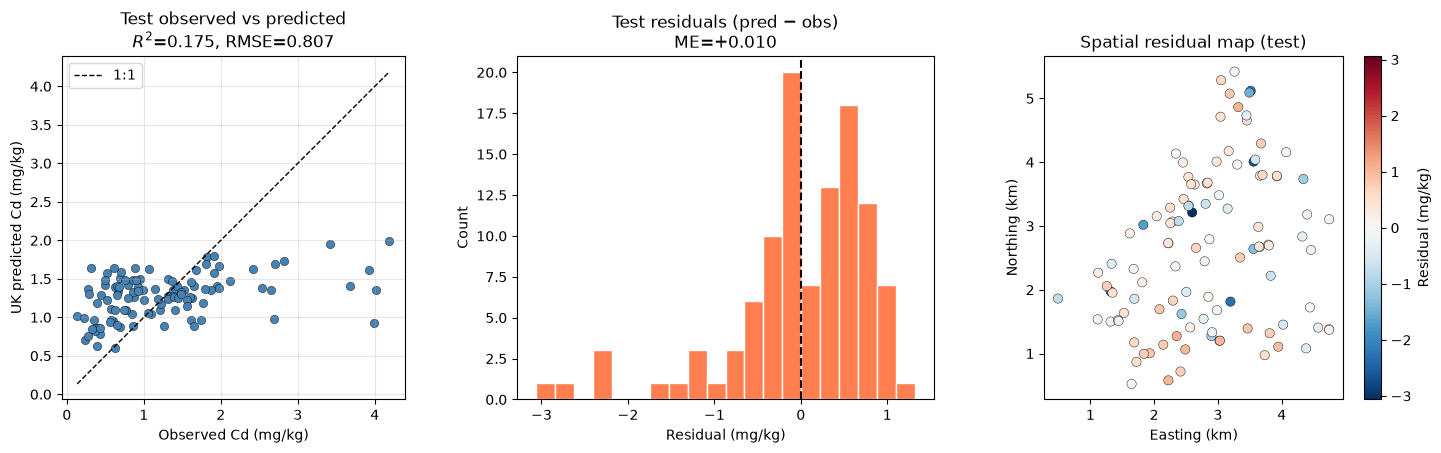

Standardized residual mean: +0.013   std: 1.039  (ideal: 0, 1)


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))

lo, hi = min(z_test.min(), z_hat.min()), max(z_test.max(), z_hat.max())
axes[0].scatter(z_test, z_hat, c="steelblue", edgecolors="k", linewidths=0.3, s=36)
axes[0].plot([lo, hi], [lo, hi], "k--", lw=1, label="1:1")
axes[0].set_xlabel("Observed Cd (mg/kg)"); axes[0].set_ylabel("UK predicted Cd (mg/kg)")
axes[0].set_title(f"Test observed vs predicted\n$R^2$={r2:.3f}, RMSE={rmse:.3f}")
axes[0].set_aspect("equal", adjustable="box"); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].hist(resid, bins=20, color="coral", edgecolor="white")
axes[1].axvline(0, color="k", ls="--")
axes[1].set_title(f"Test residuals (pred − obs)\nME={me:+.3f}")
axes[1].set_xlabel("Residual (mg/kg)"); axes[1].set_ylabel("Count")

sc = axes[2].scatter(df_test[x_col], df_test[y_col], c=resid, cmap="RdBu_r",
                     s=45, edgecolors="k", linewidths=0.3,
                     vmin=-np.max(np.abs(resid)), vmax=np.max(np.abs(resid)))
plt.colorbar(sc, ax=axes[2], label="Residual (mg/kg)")
axes[2].set_aspect("equal")
axes[2].set_title("Spatial residual map (test)")
axes[2].set_xlabel("Easting (km)"); axes[2].set_ylabel("Northing (km)")

plt.tight_layout(); plt.show()

std_resid = resid / np.clip(se_test, 1e-8, None)
print(f"Standardized residual mean: {std_resid.mean():+.3f}   std: {std_resid.std():.3f}  (ideal: 0, 1)")

***
## 11. Predict Cd on the Jura Grid

Apply the fitted UK model to every node in `jura_grid.csv`.

In [15]:
pred_grid, se_grid = uk.predict(grid_coords, return_variance=True)

grid_out = grid.copy()
grid_out["Cd_pred"] = pred_grid
grid_out["Cd_se"] = se_grid
grid_out["Cd_trend"] = trend_grid

print(f"Grid predictions: n = {len(pred_grid)}")
print(f"  Cd_pred  min/mean/max : {pred_grid.min():.3f} / {pred_grid.mean():.3f} / {pred_grid.max():.3f} mg/kg")
print(f"  Cd_se    min/mean/max : {se_grid.min():.3f} / {se_grid.mean():.3f} / {se_grid.max():.3f} mg/kg")
grid_out[[x_col, y_col, "Cd_trend", "Cd_pred", "Cd_se"]].head()

Grid predictions: n = 5957
  Cd_pred  min/mean/max : 0.241 / 1.340 / 3.230 mg/kg
  Cd_se    min/mean/max : 0.767 / 0.789 / 1.112 mg/kg


,Xloc,Yloc,Cd_trend,Cd_pred,Cd_se
0,0.30,1.70,1.888550,1.745468,0.978572
1,0.35,1.70,1.829771,1.690612,0.950946
2,0.35,1.75,1.862980,1.718402,0.951779
3,0.40,1.70,1.774263,1.637043,0.925412
4,0.40,1.75,1.805828,1.663920,0.926077


***
## 12. Map Predicted Concentration and Error

The UK prediction is the drift plus a spatially correlated residual. The error map is the kriging standard error of that combination: it grows away from samples and also where the polynomial is extrapolated (domain edges).

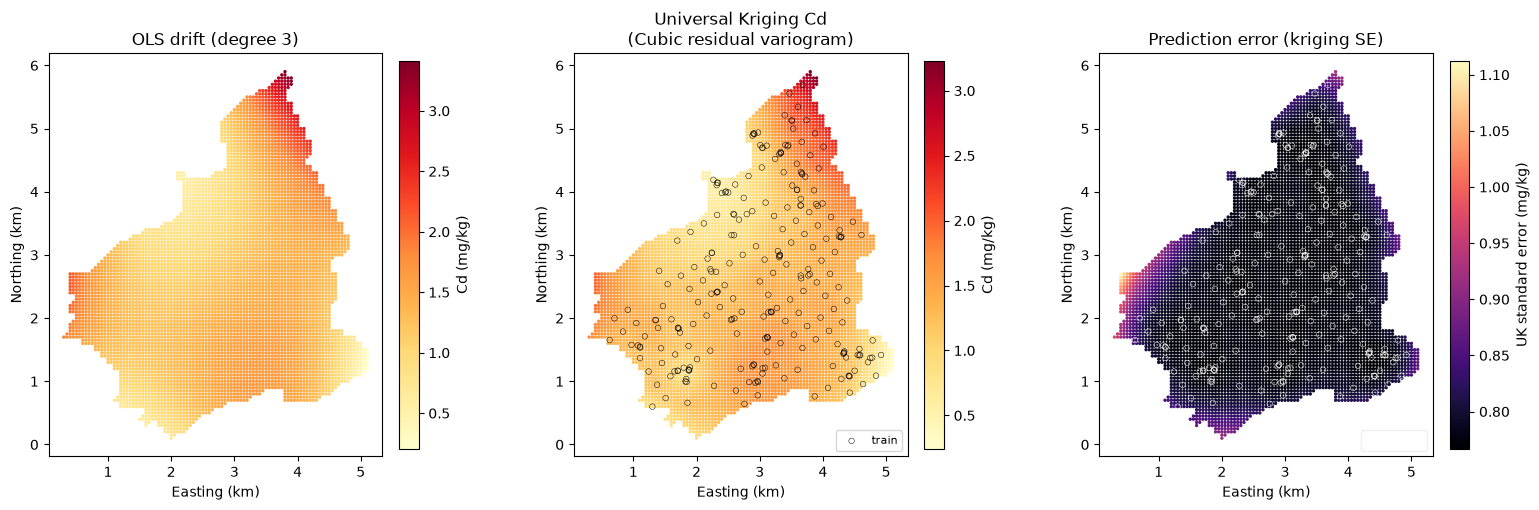

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5.2))

sc0 = axes[0].scatter(grid_out[x_col], grid_out[y_col], c=grid_out["Cd_trend"],
                      cmap="YlOrRd", s=8, marker=".")
plt.colorbar(sc0, ax=axes[0], label="Cd (mg/kg)", fraction=0.046, pad=0.04)
axes[0].set_aspect("equal")
axes[0].set_title(f"OLS drift (degree {best_degree})")
axes[0].set_xlabel("Easting (km)"); axes[0].set_ylabel("Northing (km)")

sc1 = axes[1].scatter(grid_out[x_col], grid_out[y_col], c=grid_out["Cd_pred"],
                      cmap="YlOrRd", s=8, marker=".")
axes[1].scatter(df_train[x_col], df_train[y_col], facecolors="none", edgecolors="k",
                s=16, linewidths=0.35, label="train")
plt.colorbar(sc1, ax=axes[1], label="Cd (mg/kg)", fraction=0.046, pad=0.04)
axes[1].set_aspect("equal")
axes[1].set_title(f"Universal Kriging Cd\n({best_name} residual variogram)")
axes[1].set_xlabel("Easting (km)"); axes[1].set_ylabel("Northing (km)")
axes[1].legend(loc="lower right", fontsize=8)

sc2 = axes[2].scatter(grid_out[x_col], grid_out[y_col], c=grid_out["Cd_se"],
                      cmap="magma", s=8, marker=".")
axes[2].scatter(df_train[x_col], df_train[y_col], facecolors="none", edgecolors="w",
                s=16, linewidths=0.35, label="train")
plt.colorbar(sc2, ax=axes[2], label="UK standard error (mg/kg)", fraction=0.046, pad=0.04)
axes[2].set_aspect("equal")
axes[2].set_title("Prediction error (kriging SE)")
axes[2].set_xlabel("Easting (km)"); axes[2].set_ylabel("Northing (km)")
axes[2].legend(loc="lower right", fontsize=8, labelcolor="white", framealpha=0.3)

plt.tight_layout(); plt.show()

***
## 13. Probability Maps of Exceedance

Under the Gaussian UK model,

$$
P(\text{Cd}(\mathbf{x}_0) > z_c) = 1 - \Phi\!\left(\frac{z_c - \hat{Z}_{\text{UK}}(\mathbf{x}_0)}{\sigma_{\text{UK}}(\mathbf{x}_0)}\right).
$$

Cutoffs: **0.10, 0.25, 0.50, 0.75, and 1.00 mg/kg**.

In [17]:
cutoffs = [0.10, 0.25, 0.50, 0.75, 1.00]   # mg/kg
se_safe = np.clip(se_grid, 1e-8, None)

prob_cols = []
for zc in cutoffs:
    col = f"P_Cd_gt_{zc:.2f}".replace(".", "p")
    grid_out[col] = 1.0 - norm.cdf((zc - pred_grid) / se_safe)
    prob_cols.append(col)
    print(f"P(Cd > {zc:4.2f})  mean={grid_out[col].mean():.3f}  "
          f"min={grid_out[col].min():.3f}  max={grid_out[col].max():.3f}")

emp = {zc: float(np.mean(z_train > zc)) for zc in cutoffs}
print("\nEmpirical P(Cd > zc) on training samples:")
for zc, p in emp.items():
    print(f"  {zc:4.2f} mg/kg : {p:.3f}")

P(Cd > 0.10)  mean=0.928  min=0.564  max=1.000
P(Cd > 0.25)  mean=0.900  min=0.496  max=0.999
P(Cd > 0.50)  mean=0.838  min=0.383  max=0.999
P(Cd > 0.75)  mean=0.755  min=0.280  max=0.997
P(Cd > 1.00)  mean=0.653  min=0.193  max=0.993

Empirical P(Cd > zc) on training samples:
  0.10 mg/kg : 1.000
  0.25 mg/kg : 0.976
  0.50 mg/kg : 0.873
  0.75 mg/kg : 0.701
  1.00 mg/kg : 0.546


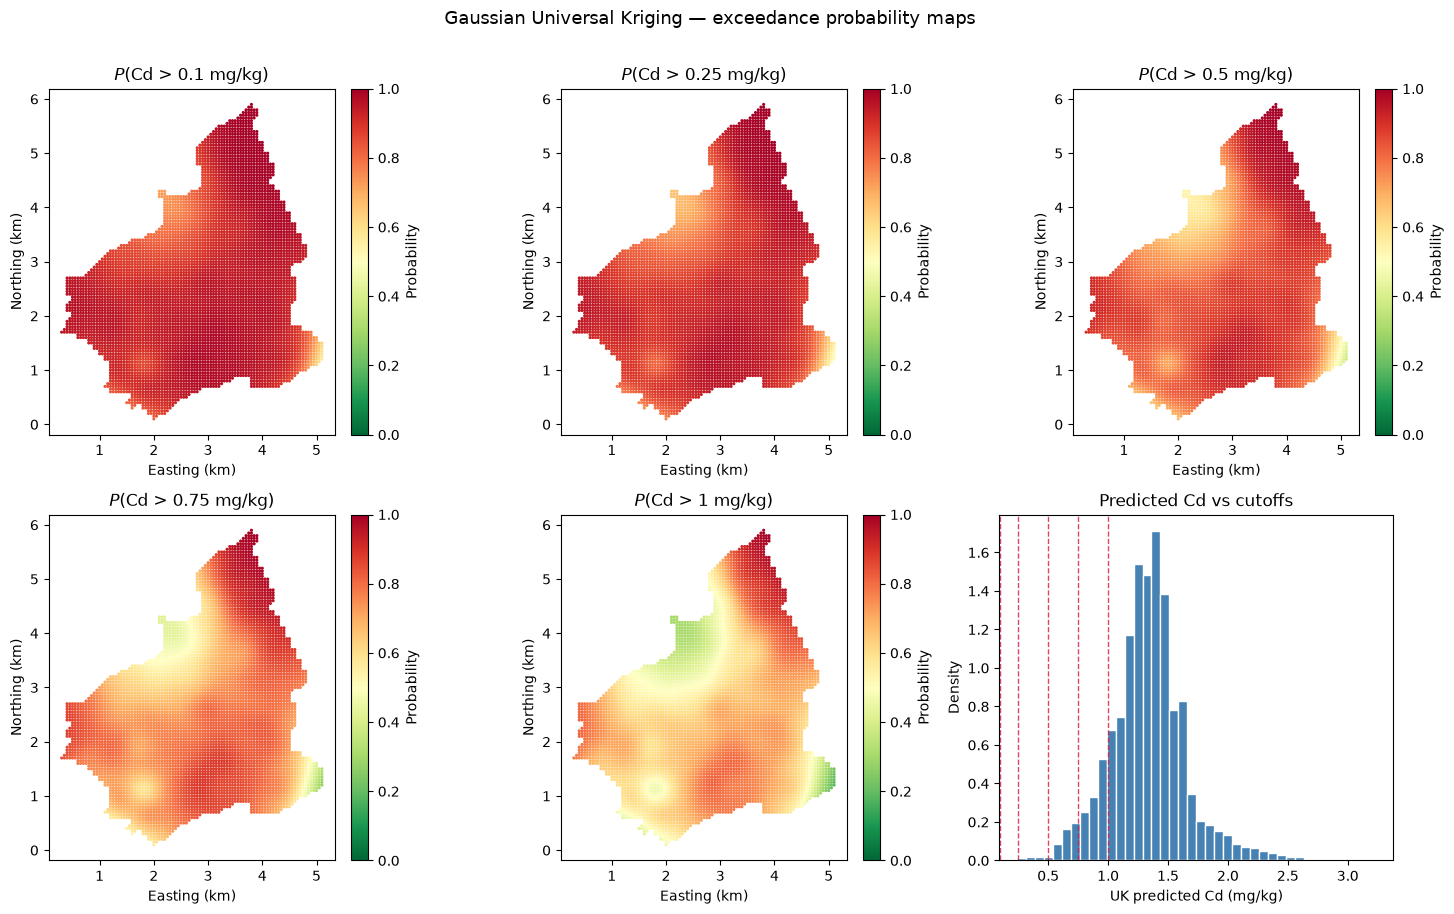

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.ravel()

for ax, zc, col in zip(axes, cutoffs, prob_cols):
    sc = ax.scatter(grid_out[x_col], grid_out[y_col], c=grid_out[col],
                    cmap="RdYlGn_r", s=6, marker=".", vmin=0, vmax=1)
    plt.colorbar(sc, ax=ax, fraction=0.046, pad=0.04, label="Probability")
    ax.set_aspect("equal")
    ax.set_title(f"$P$(Cd > {zc:g} mg/kg)")
    ax.set_xlabel("Easting (km)"); ax.set_ylabel("Northing (km)")

axes[5].hist(pred_grid, bins=40, color="steelblue", edgecolor="white", density=True)
for zc in cutoffs:
    axes[5].axvline(zc, color="crimson", ls="--", lw=1, alpha=0.8)
axes[5].set_title("Predicted Cd vs cutoffs")
axes[5].set_xlabel("UK predicted Cd (mg/kg)"); axes[5].set_ylabel("Density")

plt.suptitle("Gaussian Universal Kriging — exceedance probability maps", fontsize=13, y=1.01)
plt.tight_layout(); plt.show()

In [19]:
se_test_safe = np.clip(se_test, 1e-8, None)
rows = []
for zc in cutoffs:
    p_hat = 1.0 - norm.cdf((zc - z_hat) / se_test_safe)
    y_ind = (z_test > zc).astype(float)
    brier = float(np.mean((p_hat - y_ind) ** 2))
    rows.append({
        "cutoff_mgkg": zc,
        "empirical_rate_test": round(float(y_ind.mean()), 3),
        "mean_predicted_P": round(float(p_hat.mean()), 3),
        "Brier": round(brier, 4),
    })
pd.DataFrame(rows).set_index("cutoff_mgkg")

,empirical_rate_test,mean_predicted_P,Brier
cutoff_mgkg,,,
0.10,1.000,0.921,0.0091
0.25,0.972,0.891,0.0329
0.50,0.824,0.824,0.1247
0.75,0.639,0.735,0.2110
1.00,0.509,0.628,0.2415


***
## 14. CPU vs GPU UK Timing

Section 4.1 showed how to *select* a backend. Here we measure how long **universal kriging** takes on **CPU** (`use_gpu=False`, NumPy/SciPy) versus **GPU** (`use_gpu=True`, CuPy) — first on the Jura samples ($n_{\text{train}} = 359$) predicting the Jura grid, then on prefixes of the Great Plains soil-organic-carbon survey (`data/gp_data_5000.csv`, $n$ up to 5{,}000).

The GPU-accelerated steps are the $n \times n$ covariance matrix among training points, the $n_{\text{pred}} \times n$ covariance to the targets, and the linear solve of the **augmented** UK system (polynomial drift columns plus Lagrange multipliers). The drift matrix itself is built on CPU. Variogram fitting is done once per dataset (spherical model) and is **not** included in the UK times. All jobs use a **linear drift** (`degree=1`) so CPU vs GPU is compared on the same UK system across datasets; the rest of this notebook still uses the AIC-selected Jura degree.

Two practical notes:

- **Small $n$ and few targets** (a few hundred training *and* prediction points) often shows little GPU gain: host→device copies and kernel-launch overhead dominate.
- **Larger $n$**, or a **dense prediction grid**, is where the GPU pays off: the UK system scales as $O(n^3)$ for the solve and $O(n \cdot n_{\text{pred}})$ for the target covariances.

Each timing is the **median** of three `UniversalKriging.fit` + `predict(..., return_variance=True)` calls after a short GPU warmup so CUDA kernel compilation is not counted. If CuPy cannot run a kernel here, the GPU column is skipped and only CPU times are reported.


GPU usable : True
UK degree  : 1  (linear drift)
Repeats    : 3  (median wall time of UK fit + predict)
Jura Cd    : 359 samples → 5957 grid nodes
GP SOC     : 5000 samples from data/gp_data_5000.csv
GP n_pred  : 500 locations drawn from each prefix

  dataset  n_train  n_pred  CPU (ms)  GPU (ms) speedup  match
Jura (Cd)      359    5957     141.9      19.2   7.38×   True
 GP (SOC)      500     500      50.1      11.6   4.32×   True
 GP (SOC)     1000     500     138.6      24.3   5.70×   True
 GP (SOC)     2000     500     374.0      65.0   5.75×   True
 GP (SOC)     4000     500    1343.2     206.4   6.51×   True
 GP (SOC)     5000     500    2159.1     358.7   6.02×   True


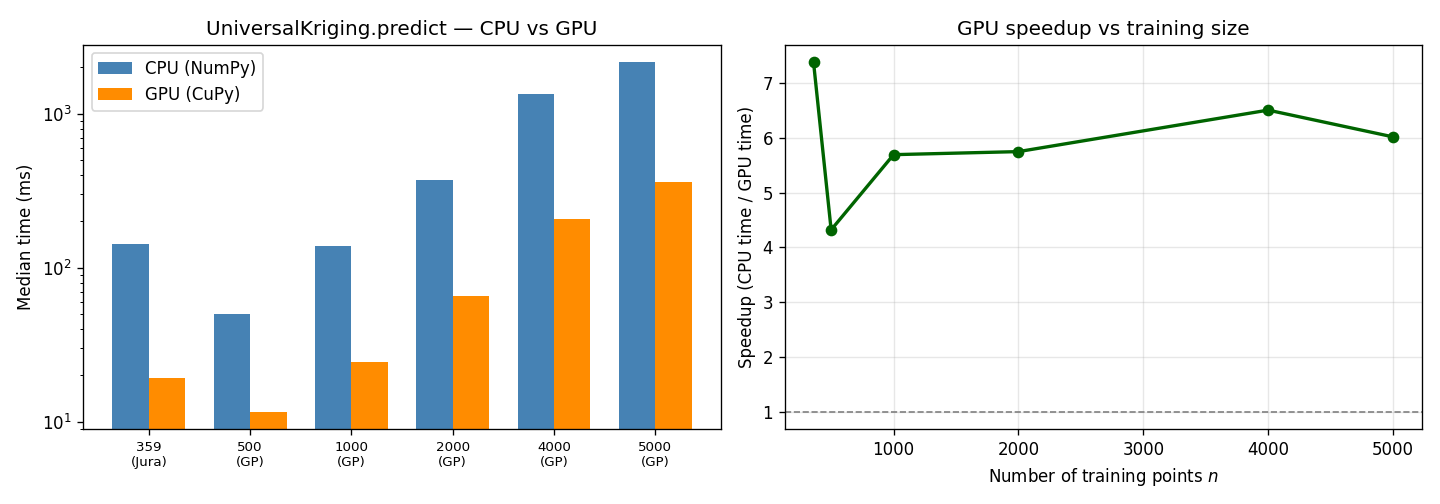

In [18]:
import time

N_LAGS = 12
N_REPEATS = 3
N_PRED_GP = 500
GP_SIZES = [500, 1000, 2000, 4000, 5000]
UK_DEGREE = 1  # linear drift for a fair CPU/GPU comparison across datasets

df_gp = pd.read_csv("../data/gp_data_5000.csv")
gp_coords = df_gp[["x", "y"]].to_numpy(dtype=float)
gp_vals = df_gp["SOC"].to_numpy(dtype=float)
rng = np.random.default_rng(42)


def _fit_spherical(xy, values, use_gpu=False):
    return Variogram(
        np.asarray(xy, dtype=float),
        np.asarray(values, dtype=float),
        model="spherical",
        n_lags=N_LAGS,
        use_gpu=use_gpu,
    ).fit()


def _time_uk(xy_train, z_train, xy_pred, vg, use_gpu, degree=UK_DEGREE, repeats=N_REPEATS, warmup=True):
    """Median wall time of UniversalKriging.fit + predict(return_variance=True)."""
    if warmup:
        k_tr = min(40, len(xy_train))
        k_pr = min(40, len(xy_pred))
        UniversalKriging(vg, degree=degree, use_gpu=use_gpu).fit(
            xy_train[:k_tr], z_train[:k_tr]
        ).predict(xy_pred[:k_pr], return_variance=True)
        if use_gpu:
            import cupy as cp
            cp.cuda.Device(0).synchronize()
    times = []
    last = None
    for _ in range(repeats):
        t0 = time.perf_counter()
        uk_m = UniversalKriging(vg, degree=degree, use_gpu=use_gpu).fit(xy_train, z_train)
        last = uk_m.predict(xy_pred, return_variance=True)
        if use_gpu:
            import cupy as cp
            cp.cuda.Device(0).synchronize()
        times.append(time.perf_counter() - t0)
    return float(np.median(times)), last


jobs = [{
    "dataset": "Jura (Cd)",
    "n_obs": len(coords),
    "xy_train": np.asarray(coords, dtype=float),
    "z_train": np.asarray(z, dtype=float),
    "xy_pred": np.asarray(grid_coords, dtype=float),
}]
for n in GP_SIZES:
    n_pred = min(N_PRED_GP, n)
    pred_idx = rng.choice(n, size=n_pred, replace=False)
    jobs.append({
        "dataset": "GP (SOC)",
        "n_obs": n,
        "xy_train": gp_coords[:n],
        "z_train": gp_vals[:n],
        "xy_pred": gp_coords[pred_idx],
    })

print(f"GPU usable : {USE_GPU}")
print(f"UK degree  : {UK_DEGREE}  (linear drift)")
print(f"Repeats    : {N_REPEATS}  (median wall time of UK fit + predict)")
print(f"Jura Cd    : {len(coords)} samples → {len(grid_coords)} grid nodes")
print(f"GP SOC     : {len(gp_vals)} samples from data/gp_data_5000.csv")
print(f"GP n_pred  : {N_PRED_GP} locations drawn from each prefix")
print()

rows = []
for job in jobs:
    xy_tr, z_tr, xy_pr = job["xy_train"], job["z_train"], job["xy_pred"]
    vg = _fit_spherical(xy_tr, z_tr, use_gpu=False)

    cpu_t, pred_cpu = _time_uk(xy_tr, z_tr, xy_pr, vg, use_gpu=False)
    row = {
        "dataset": job["dataset"],
        "n_train": len(xy_tr),
        "n_pred": len(xy_pr),
        "CPU (s)": cpu_t,
        "GPU (s)": np.nan,
        "speedup": np.nan,
        "match": "—",
    }

    if USE_GPU:
        gpu_t, pred_gpu = _time_uk(xy_tr, z_tr, xy_pr, vg, use_gpu=True)
        row["GPU (s)"] = gpu_t
        row["speedup"] = cpu_t / gpu_t
        z_c, se_c = pred_cpu
        z_g, se_g = pred_gpu
        row["match"] = bool(
            np.allclose(z_c, z_g, rtol=1e-4, atol=1e-4, equal_nan=True)
            and np.allclose(se_c, se_g, rtol=1e-4, atol=1e-4, equal_nan=True)
        )
        import cupy as cp
        cp.get_default_memory_pool().free_all_blocks()
    rows.append(row)

df_bench = pd.DataFrame(rows)
df_show = df_bench.copy()
df_show["CPU (ms)"] = (df_show["CPU (s)"] * 1000).round(1)
df_show["GPU (ms)"] = (df_show["GPU (s)"] * 1000).round(1)
df_show["speedup"] = df_show["speedup"].map(
    lambda x: "—" if pd.isna(x) else f"{x:.2f}×"
)
print(df_show[["dataset", "n_train", "n_pred", "CPU (ms)", "GPU (ms)", "speedup", "match"]].to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
n_vals = df_bench["n_train"].to_numpy()
cpu_ms = df_bench["CPU (s)"].to_numpy() * 1000
gpu_ms = df_bench["GPU (s)"].to_numpy() * 1000
labels = [
    f"{int(n)}\n({ds.split()[0]})"
    for n, ds in zip(n_vals, df_bench["dataset"])
]

x = np.arange(len(n_vals))
w = 0.36
axes[0].bar(x - w / 2, cpu_ms, w, label="CPU (NumPy)", color="steelblue")
if USE_GPU and np.isfinite(gpu_ms).all():
    axes[0].bar(x + w / 2, gpu_ms, w, label="GPU (CuPy)", color="darkorange")
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels, fontsize=8)
axes[0].set_ylabel("Median time (ms)")
axes[0].set_title("UniversalKriging.predict — CPU vs GPU")
axes[0].legend()
axes[0].set_yscale("log")

if USE_GPU:
    axes[1].plot(n_vals, df_bench["speedup"], "o-", color="darkgreen", lw=2)
    axes[1].axhline(1.0, color="grey", ls="--", lw=1)
    axes[1].set_xlabel("Number of training points $n$")
    axes[1].set_ylabel("Speedup (CPU time / GPU time)")
    axes[1].set_title("GPU speedup vs training size")
    axes[1].grid(True, alpha=0.3)
else:
    axes[1].text(
        0.5, 0.5,
        "GPU not usable in this environment\nCPU-only timings shown",
        ha="center", va="center", transform=axes[1].transAxes,
    )
    axes[1].set_axis_off()

plt.tight_layout()
plt.show()


Predictions and kriging standard errors from the two backends should **match** (`match = True`). On this workstation the Jura run still benefits from the GPU because we predict 5{,}957 grid nodes even though $n = 359$ is small. On the Great Plains SOC prefixes the $O(n^2)$ covariance build and $O(n^3)$ solve keep the GPU several times faster as $n$ grows to 5{,}000. Use `use_gpu=USE_GPU` (as the rest of this notebook does) so the same cells run on a laptop CPU or a CUDA workstation without edits.


***
## 15. Summary and Conclusions

This tutorial walked through a complete **universal kriging** workflow for Jura cadmium.

### What we did

1. Split 359 samples **70 / 30** with **stratified random sampling by Landuse**.
2. Compared polynomial drifts of **degree 0, 1, 2, and 3** on training Cd and selected $d^\star$ by **AIC**.
3. Fitted six theoretical **residual** variograms and selected the best by AIC.
4. Fitted **Universal Kriging** with that degree, residual covariance, and `use_gpu=USE_GPU`.
5. Validated at held-out locations (RMSE, MAE, mean error, $R^2$).
6. Mapped the OLS drift, the UK prediction, and the kriging standard error on `jura_grid.csv`.
7. Converted $(\hat{Z},\sigma_{\text{UK}})$ into Gaussian exceedance probabilities at 0.10, 0.25, 0.50, 0.75, and 1.00 mg/kg.
8. Timed `UniversalKriging.predict` on **CPU vs GPU** for Jura Cd and prefixes of `data/gp_data_5000.csv`.

### Practical takeaways

- **Fit the variogram to residuals**, not to raw Cd. A trend in $Z$ inflates the experimental variogram and confuses range and sill.
- Degree 0 UK is ordinary kriging. Use a higher degree only if AIC (and residual maps) justify it.
- High-degree polynomials **extrapolate badly** at the edge of the domain; watch the SE map there.
- UK variance is larger than OK/SK variance because more mean parameters are estimated.
- Gaussian $P(\text{Cd} > z_c)$ is an approximation for skewed concentrations; indicator kriging is the nonparametric alternative.
- A GPU pays off for UK when $n$ is large *or* you predict a dense grid. The polynomial drift matrix stays on CPU; the $O(n^3)$ solve is what the GPU accelerates.

### Next steps

- Compare test RMSE with Tutorials 02 (SK) and 03 (OK) on this same split
- Regression kriging: replace the polynomial with land use / rock type as covariates
- Indicator kriging for the same five cutoffs without the Gaussian assumption


***
## 16. Resources

### Textbooks

| Reference | Notes |
|-----------|-------|
| Goovaerts, P. (1997). *Geostatistics for Natural Resources Evaluation*. Oxford University Press. | UK and residual variograms; Jura Cd |
| Chilès, J.-P. & Delfiner, P. (2012). *Geostatistics: Modeling Spatial Uncertainty* (2nd ed.). Wiley. | UK system and drift |
| Cressie, N. (1993). *Statistics for Spatial Data* (rev. ed.). Wiley. | Universal kriging as GLS with covariance $C$ |
| Wackernagel, H. (2003). *Multivariate Geostatistics* (3rd ed.). Springer. | Polynomial drift and IRF-$k$ |

### Key papers

| Paper | Contribution |
|-------|----------------|
| Matheron, G. (1969). *Le krigeage universel*. Cahiers du Centre de Morphologie Mathématique. | Original UK |
| Cressie, N. (1990). The origins of kriging. *Mathematical Geology* 22, 239–252. | UK in the BLUP / GLS family |
| Journel, A.G. & Rossi, M.E. (1989). When do we need a trend model in kriging? *Mathematical Geology* 21, 715–739. | When a drift is (and is not) needed |

### In this library

| Object | Role |
|--------|------|
| `pygstat.Variogram` | Fit on **residuals** of the chosen trend |
| `pygstat.UniversalKriging` | `degree` polynomial drift; `predict(..., return_variance=True)`; `use_gpu=True|False|'auto'` |
| `pygstat.OrdinaryKriging` | Degree-0 special case (Tutorial 03) |
| `pygstat.SimpleKriging` | Known-mean special case (Tutorial 02) |
